# Clinical NLP Risk Classification for Sickle Cell Emergency Department Notes

## Project Overview

This portfolio project explores whether free-text clinical notes and structured visit-level data can be used to classify sickle cell emergency department visits into two outcomes:

1. whether the visit resulted in admission;
2. whether the visit met a clinically defined high-risk profile.

The project combines natural language processing with structured clinical features such as haemoglobin, oxygen saturation, pain intensity, previous visits, previous admissions, and changes in laboratory values over time.

The aim is not only to train predictive models, but to compare how different modelling approaches behave on two related clinical classification tasks. Traditional machine learning models and LSTM-based models are evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

A key distinction in this project is the difference between the original admission outcome and the engineered high-risk outcome. Admission may depend on clinical judgement, bed availability, hospital policy, or other factors not captured in the dataset. The high-risk label is based directly on clinical indicators available in the data, making it a more interpretable modelling target.

## Reproducibility Note

This notebook preserves the original executed outputs from the project. Some models, especially the deep learning sections, can take time to rerun depending on the available hardware. For portfolio review, the notebook is intended to show the full workflow, modelling decisions, and evaluated outputs without requiring every cell to be rerun immediately.


## Dataset

The dataset used in this project is the Sickle Cell Clinical Notes dataset from Kaggle. It contains emergency and clinical visit records for patients with sickle cell disease. Each record includes structured variables such as patient ID, visit date, facility type, pain type, pain intensity, admission status, haemoglobin, oxygen saturation, date of birth, diagnosis date, gender, and a free-text clinical note.

After preprocessing, the dataset contained 75,016 visits from 5,000 patients. The original admission label was almost balanced, with approximately 50.1% of visits resulting in admission. A second target variable, high_risk, was engineered using simple clinical rules based on haemoglobin, oxygen saturation, and pain intensity. This high-risk label was positive in approximately 59.5% of visits.

The dataset was treated as a clinical NLP task with structured data. The free-text notes were cleaned and vectorised, while structured clinical and patient-history features were engineered and combined with text-based features for modelling.


## Problem Definition

This project is framed as a binary classification task with two target labels.

The first target is admitted_bin, which indicates whether a visit resulted in admission. This represents the original operational outcome in the dataset.

The second target is high_risk, an engineered clinical risk label. A visit was classified as high risk if at least one of the following conditions was present:

1. haemoglobin below 8.0 g/dL;

2. oxygen saturation below 90%;

3. pain intensity of 8 or above.

The purpose of creating this second target was to test whether the available clinical notes and structured features could identify visits with clinically concerning patterns, even when the original admission decision was difficult to predict.


In [1]:
import pandas as pd
import numpy as np
import re
# import kagglehub
# Download latest version
#path = kagglehub.dataset_download("jadeacevedo/sickle-cell-clinical-notes")

#print("Path to dataset files:", path)

In [2]:
#Reading in data
df = pd.read_csv('sickle_cell_clinical_notes.csv')
df.head()

,patient_id,visit_datetime,facility_type,pain_type,pain_intensity,location,admitted,hemoglobin,oxygen_saturation,clinical_note,dob,diagnosis_date,gender
0,P00000,10/8/20,ER,Leg Pain,2,Bronx,Yes,6.6,98,45-year-old Female with a known history of sic...,10/27/16,7/16/20,Female
1,P00000,12/26/20,Clinic,Chest Pain,8,Queens,Yes,6.7,92,45-year-old Female with a known history of sic...,10/27/16,7/16/20,Female
2,P00000,2/21/21,Outpatient,Chest Pain,4,Staten Island,No,10.5,88,45-year-old Female with a known history of sic...,10/27/16,7/16/20,Female
3,P00000,8/7/21,Clinic,Leg Pain,8,Manhattan,No,9.2,95,45-year-old Female with a known history of sic...,10/27/16,7/16/20,Female
4,P00000,10/4/21,Urgent Care,Back Pain,6,Bronx,No,7.8,91,45-year-old Female with a known history of sic...,10/27/16,7/16/20,Female


## Preprocessing and Feature Engineering


In [3]:
# 1.Cleaning text with but keeping numbers
def clean_text_with_digits(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    #keep Letters, digits, and whitespace; replace everything else with a space
    text = re.sub(r'[^a-z0-9\s]', ' ', text).strip()
    return text

df["clean_notes_v2"] = df["clinical_note"].apply(clean_text_with_digits)


# Extracting agefrom the note clinical notes
def extract_age_from_note(text: str):
    """
    Extracts the patient's age in years from the clinical note text,
    by finding patterns like '45-year-old' or '45 year old'.
    """
    if pd.isna(text):
        return np.nan
    #Lower case for easier matching
    t = text.lower()

    #looking for patterns like '45-year-old' or '45 year old'
    m = re.search(r'(\d+)\s*[- ]?\s*year[- ]old', t)
    if m:
        try:
            return int(m.group(1))
        except ValueError:
            return np.nan
    return np.nan        



# 2. Temporal / Patient history

#Parsing dates
df["visit_dt"] = pd.to_datetime(df["visit_datetime"], format="%m/%d/%y", errors = "coerce")
df["dob_dt"] = pd.to_datetime(df["dob"], format="%m/%d/%y", errors = "coerce")
df["diagnosis_dt"] = pd.to_datetime(df["diagnosis_date"], format="%m/%d/%y", errors = "coerce")

#Age and years since diagnosis (at this visit)
df["age_years"] = df["clinical_note"].apply(extract_age_from_note)
df["years_since_diagnosis"] = (
    (df["visit_dt"] - df["diagnosis_dt"]).dt.days / 365.25
).round(1)

#Sort by patience and time so "previous" makes sense
df = df.sort_values(["patient_id", "visit_dt"])

g = df.groupby("patient_id", group_keys=False)

#Previous visit date and time gap
df["prev_visit_dt"] = g["visit_dt"].shift(1)
df["days_since_last_visit"] = (df["visit_dt"] - df["prev_visit_dt"]).dt.days

#Number of previous visits for this patient
df["num_prev_visits"] = g.cumcount()

#Binary admitted label for history
df["admitted_bin"] = (df["admitted"] == "Yes").astype(int)

#Number of previous admissions for this patient
df["num_prev_admissions"] = g["admitted_bin"].cumsum().shift(1).fillna(0)

# Previous labs and changes since last visit
df["prev_hemoglobin"] = g["hemoglobin"].shift(1)
df["prev_oxygen_saturation"] = g["oxygen_saturation"].shift(1)

df["delta_hemoglobin"] = df["hemoglobin"] - df["prev_hemoglobin"]
df["delta_oxygen_saturation"] = (
    df["oxygen_saturation"] - df["prev_oxygen_saturation"]
)

#3. Features Extracted from notes

#Symptom duration in days (e.g. "2-day" or "2 day")
def extract_duration_days(text: str):
    if pd.isna(text):
        return np.nan
    m= re.search(r"(\d+)\s*[- ]?\s*day", text.lower())
    if m:
        try:
            return int(m.group(1))
        except ValueError:
            return np.nan
    return np.nan

#df["symptom_duration_days"] = df["clinical_note"].apply(extract_duration_days)

#Genotype (HbSS, HbSC, HbSβ+, etc.)
def extract_genotype(text: str):
    if pd.isna(text):
        return np.nan
    #common genotype patterns
    for gt in ["HbSS", "HbSC", "HbSβ⁺", "HbSβ˚", "HbSβ0"]:
        if gt.lower() in text.lower():
            return gt
    #fallback: anything like (Hb...)
    m = re.search(r"\((hb[^)]+)\)", text, flags = re.IGNORECASE)
    if m:
        return m.group(1)
        
    return np.nan

df["genotype"] = df["clinical_note"]. apply(extract_genotype)

# Severity / Symptom Keywords
def has_keyword(text: str, keywords):
    if pd.isna(text):
        return 0
    lower = text.lower()
    return int(any(kw in lower for kw in keywords))

df["has_severe"] = df["clinical_note"].apply(
    lambda t: has_keyword(t, ["severe"])
)
df["has_mild"] = df["clinical_note"].apply(
    lambda t: has_keyword(t, ["mild"])
)
df["has_worsening"] = df["clinical_note"].apply(
    lambda t: has_keyword(t, ["worsening"])
)
df["has_shortness_of_breath"] = df["clinical_note"].apply(
    lambda t: has_keyword(t, ["shortness of breath", "sob"])
)



# 4. New Target: hig_risk visit

df["high_risk"] = (
   (df["hemoglobin"] < 8.0)
    | (df["oxygen_saturation"] < 90.0)
    | (df["pain_intensity"] >= 8)
).astype(int)

print("Original admitted rate:", df["admitted_bin"].mean())
print("High risk rate:", df["high_risk"].mean())
print("Rows:", len(df), "Patients:", df["patient_id"].nunique())

Original admitted rate: 0.500533219579823
High risk rate: 0.5951796949984003
Rows: 75016 Patients: 5000


### Preview of Engineered Features


In [44]:
cols_to_show = [
    "patient_id", "visit_datetime", "admitted", "admitted_bin", "high_risk",
    "years_since_diagnosis", "age_years",
    "num_prev_visits", "num_prev_admissions", "days_since_last_visit",
    "hemoglobin", "prev_hemoglobin", "delta_hemoglobin",
    "oxygen_saturation", "prev_oxygen_saturation", "delta_oxygen_saturation",
    "genotype",
    "has_severe", "has_mild", "has_worsening", "has_shortness_of_breath",
    "clean_notes_v2"
]

df[cols_to_show].head(5)

,patient_id,visit_datetime,admitted,admitted_bin,high_risk,years_since_diagnosis,age_years,num_prev_visits,num_prev_admissions,days_since_last_visit,...,delta_hemoglobin,oxygen_saturation,prev_oxygen_saturation,delta_oxygen_saturation,genotype,has_severe,has_mild,has_worsening,has_shortness_of_breath,clean_notes_v2
0,P00000,10/8/20,Yes,1,1,0.2,45,0,0.0,NaN,...,NaN,98,NaN,NaN,HbSS,1,0,0,1,45 year old female with a known history of sic...
1,P00000,12/26/20,Yes,1,1,0.4,45,1,1.0,79.0,...,0.1,92,98.0,-6.0,HbSS,1,0,0,1,45 year old female with a known history of sic...
2,P00000,2/21/21,No,0,1,0.6,45,2,2.0,57.0,...,3.8,88,92.0,-4.0,HbSS,1,0,0,1,45 year old female with a known history of sic...
3,P00000,8/7/21,No,0,1,1.1,45,3,2.0,167.0,...,-1.3,95,88.0,7.0,HbSS,1,0,0,1,45 year old female with a known history of sic...
4,P00000,10/4/21,No,0,1,1.2,45,4,2.0,58.0,...,-1.4,91,95.0,-4.0,HbSS,1,0,0,1,45 year old female with a known history of sic...


## Exploratory Data Analysis
This section explores key aspects of the engineered dataset:

- Note length distribution
- Class distributions for both labels
- Word frequency of clinical notes with a wordcloud
- Distribution of Key numeric features(age, years since diagnosis, labs)
- Comparison of label rates (admitted_bin (original target variable) and high_risk (engineered target variable))
- Admission and high-risk rates by facility type
- Correlations between numeric features and targets.


### Note Length Distribution


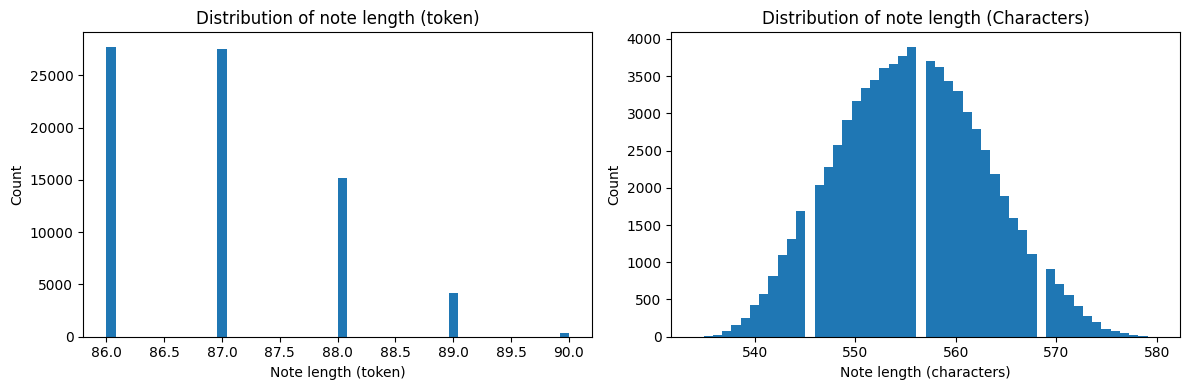

In [8]:
# Note length in words and in characters
df["note_len_tokens"] = df["clean_notes_v2"].astype(str).str.split().str.len()
df["note_len_chars"] = df["clean_notes_v2"].astype(str).str.len()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Token
plt.subplot(1, 2, 1)
plt.hist(df["note_len_tokens"], bins=50)
plt.xlabel("Note length (token)")
plt.ylabel("Count")
plt.title("Distribution of note length (token)")

# Characters
plt.subplot(1, 2, 2)
plt.hist(df["not_len_chars"], bins=50)
plt.xlabel("Note length (characters)")
plt.ylabel("Count")
plt.title("Distribution of note length (Characters)")

plt.tight_layout()
plt.show()

### Class Distribution for Both Targets


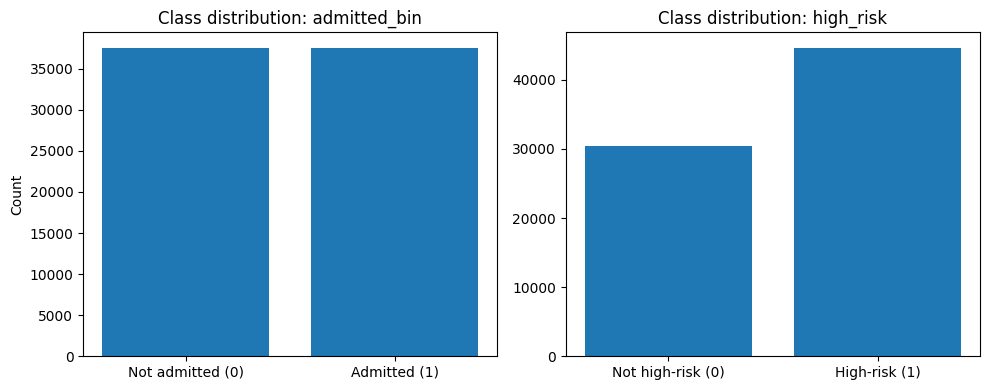

admitted_bin rates: 0.500533219579823
high_risk rates: 0.5951796949984003


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# admitted_bin
adm_counts = df["admitted"].value_counts().sort_index()
axes[0].bar(["Not admitted (0)", "Admitted (1)"], adm_counts.values)
axes[0].set_title("Class distribution: admitted_bin")
axes[0].set_ylabel("Count")

# high_risk
hr_counts = df["high_risk"].value_counts().sort_index()
axes[1].bar(["Not high-risk (0)", "High-risk (1)"], hr_counts.values)
axes[1].set_title("Class distribution: high_risk")

plt.tight_layout()
plt.show()

print("admitted_bin rates:", df["admitted_bin"].mean())
print("high_risk rates:", df["high_risk"].mean())

### Word Frequency in Clinical Notes


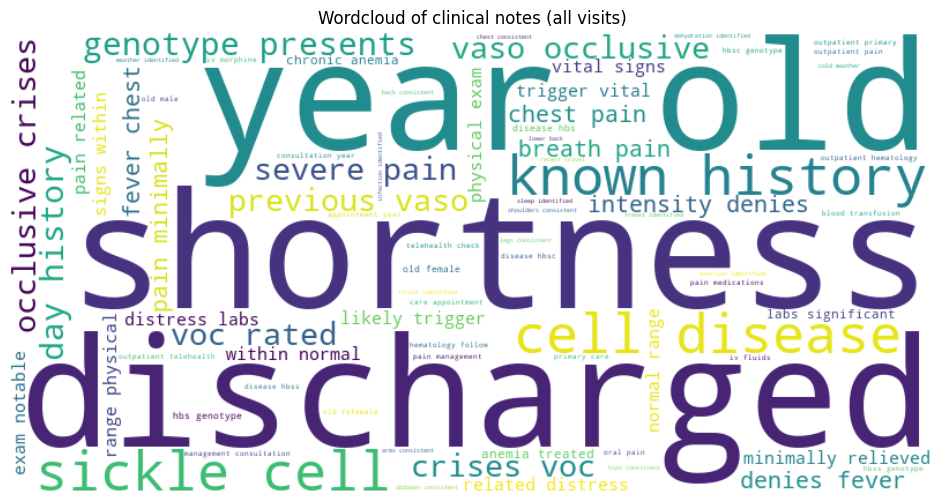

In [13]:
from wordcloud import WordCloud

all_text = " ".join(df["clean_notes_v2"].astype(str).tolist())

wc = WordCloud(width=800, height=400,
              background_color="white", max_words=200).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud of clinical notes (all visits)")
plt.show()

In [19]:
# Basic summary of Engineered numericfeatures
numeric_cols =[
    "years_since_diagnosis", "age_years",
    "num_prev_visits", "num_prev_admissions", "days_since_last_visit",
    "hemoglobin", "prev_hemoglobin", "delta_hemoglobin",
    "oxygen_saturation", "prev_oxygen_saturation", "delta_oxygen_saturation",
    "pain_intensity"
]

print("Shape:", df.shape)
print("\nLabel rates:")
print("admitted_bin mean:", df['admitted_bin'].mean())
print("high_risk mean:", df['high_risk'].mean())

print("\nNumeric feature summary:")
df[numeric_cols].describe().T

Shape: (75016, 34)

Label rates:
admitted_bin mean: 0.500533219579823
high_risk mean: 0.5951796949984003

Numeric feature summary:


,count,mean,std,min,25%,50%,75%,max
years_since_diagnosis,75016.0,2.394766,1.435071,0.1,1.2,2.3,3.4,7.3
age_years,75016.0,34.483070,17.119352,5.0,20.0,35.0,49.0,64.0
num_prev_visits,75016.0,7.331503,4.849937,0.0,3.0,7.0,11.0,19.0
num_prev_admissions,75016.0,4.164578,2.823418,0.0,2.0,4.0,6.0,18.0
days_since_last_visit,70016.0,105.038248,43.539756,30.0,68.0,105.0,143.0,180.0
hemoglobin,75016.0,8.753916,1.295351,6.5,7.6,8.8,9.9,11.0
prev_hemoglobin,70016.0,8.753366,1.295465,6.5,7.6,8.8,9.9,11.0
delta_hemoglobin,70016.0,0.001657,1.832835,-4.5,-1.3,0.0,1.3,4.5
oxygen_saturation,75016.0,93.985336,3.751055,88.0,91.0,94.0,97.0,100.0
prev_oxygen_saturation,70016.0,93.980233,3.750447,88.0,91.0,94.0,97.0,100.0


### Interpretation
The dataset contains 75,016 visits. The original admission label (admitted_bin) almost balanced (50.1%), while the engineered high_risk label is positive in 59.5% of visits. Patients are between 5 and 64 years old, with an average age of about 34, so this cohort includes both younger and older adults. Patients have A mean disease duration of 2.4 years (range 0.1 - 7.3), an average of 7.3 previous visits and 4.2 previous admissions, with visit intervals of roughly 105 days (IQR 68-143). Hemoglobin and oxygen saturation values are within plausible ranges for sickle cell disease (Hb 6.5-11.0g/dL, SpO2 88-100%), and visit to visit changes in these labs are centered around zero. Pain intensity is well distributed from 1 to 10 (median 5, IQR 3-8), supporting its use in defining the high_risk outcome.


### Age and Years Since Diagnosis


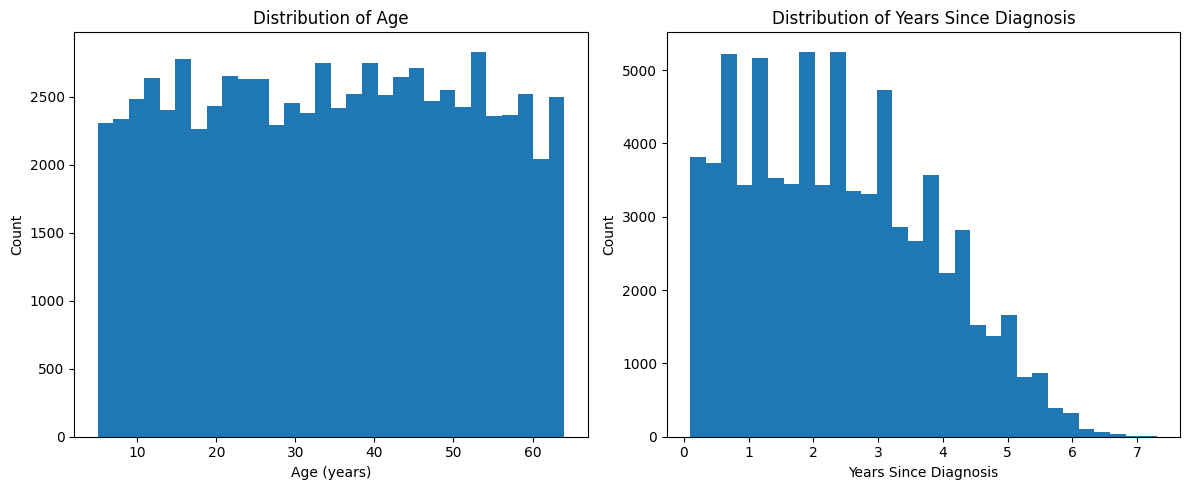

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

#Plot for age_years
plt.subplot(1, 2, 1)
df['age_years'].dropna().plot(kind='hist', bins=30)
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.title('Distribution of Age')

#Plot for years_since_diagnosis
plt.subplot(1, 2, 2)
df['years_since_diagnosis'].dropna().plot(kind='hist', bins=30)
plt.xlabel('Years Since Diagnosis')
plt.ylabel('Count')
plt.title('Distribution of Years Since Diagnosis')

plt.tight_layout()
plt.show()

### Interpretation
The age distribution is fairly flat between about 5 and 64 years, which means we have patients spread across a wide age range rather than clustered in a single group. in contrast, the "years since diagnosis" distribution is right-skewed, indicating that most patient were diagnosed within the last 1-4 years, with progressively fewer patients having a longer disease duration beyond that.


### Haemoglobin and Oxygen Saturation Distributions


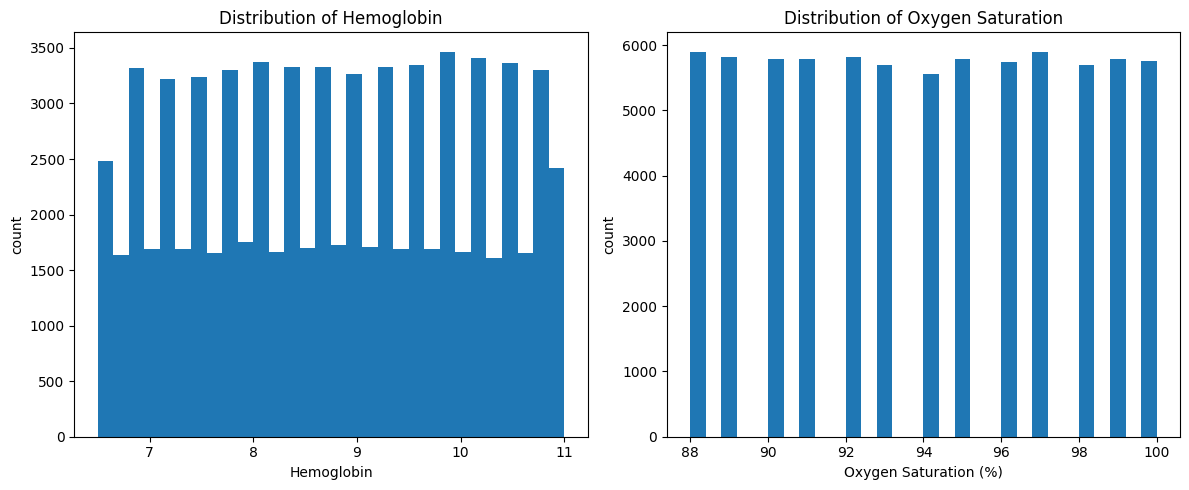

In [25]:
plt.figure(figsize=(12, 5))

#plot for hemoglobin
plt.subplot(1, 2, 1)
df['hemoglobin'].plot(kind='hist', bins=30)
plt.xlabel('Hemoglobin')
plt.ylabel('count')
plt.title('Distribution of Hemoglobin')

#Plot for Oxygen saturation
plt.subplot(1, 2, 2)
df['oxygen_saturation'].plot(kind='hist', bins=30)
plt.xlabel('Oxygen Saturation (%)')
plt.ylabel('count')
plt.title('Distribution of Oxygen Saturation')

plt.tight_layout()
plt.show()

### Interpretation
Hemoglobin values are spread fairly and evenly between about 6.5 and 11 g/dL, with no extreme outliers, which is consistent with chronic anemia in sickle cell disease. Oxygen saturation is mostly high, ranging from 88% to 100%, with many visit clustered in the mid-90s. This pattern suggest that while most patients are reasonably well oxygenated, a non-trivial number of visits fall into lower saturation ranges, supporting its use as part of the high_risk definition.


### Admission and High-Risk Rates by Facility Type


               admitted_bin  high_risk
facility_type                         
Clinic             0.499647   0.594396
ER                 0.506432   0.602270
Outpatient         0.493547   0.592716
Urgent Care        0.502690   0.591508


<Figure size 800x500 with 0 Axes>

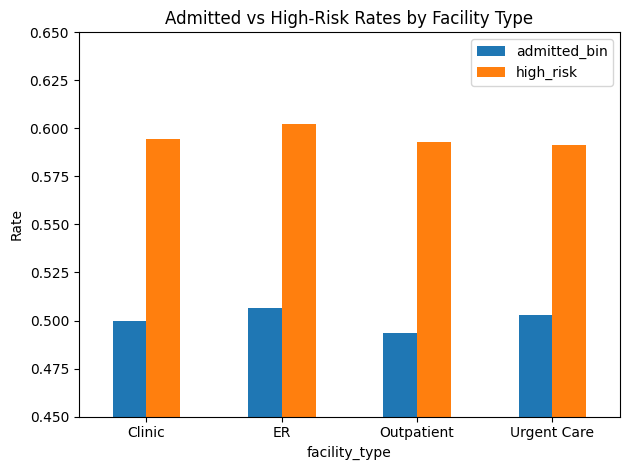

In [31]:
facility_stats = df.groupby('facility_type')[['admitted_bin', 'high_risk']].mean()

print(facility_stats)

plt.figure(figsize=(8, 5))
facility_stats.plot(kind='bar')
plt.ylabel('Rate')
plt.title('Admitted vs High-Risk Rates by Facility Type')
plt.ylim(0.45, 0.65)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation
When we compare admission and high risk rates across facility types, we see that admission rates are very similar everywhere, sitting around 49-51%. ER has the highest admission rate (~ 50.6%), and Outpatient the lowest (~ 49.4%), but the differences are small. In contrast, the proportion of high-risk visits is consistently higher in every setting (about 59-60%), which suggest that many visits that look clinically high-risk on vitals and pain are not always admitted, and that admission decisions likely depend on additional factors beyond the features observed in the original dataset.


### Correlation Between Numeric Features and Targets


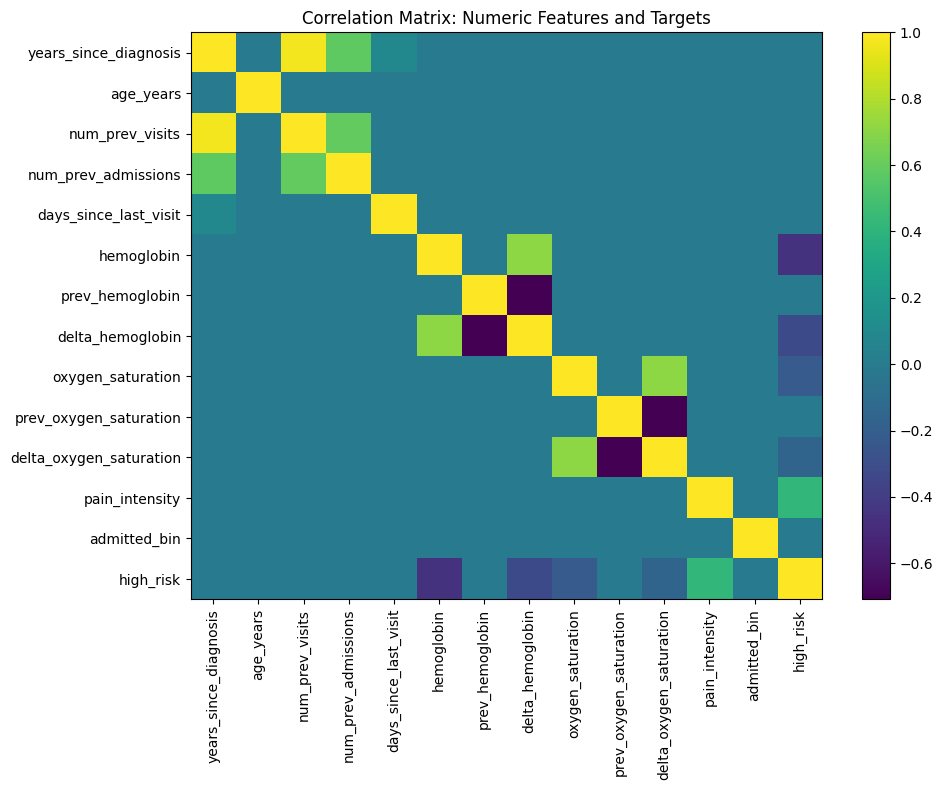

In [32]:
corr_cols = numeric_cols + ['admitted_bin', 'high_risk']
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect = 'auto')
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation = 90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Correlation Matrix: Numeric Features and Targets')
plt.tight_layout()
plt.show()

### Interpretation
The correlation matrix shows a few expected clusters. Years since diagnosis is strongly related to the number of previous visits and admissions, which makes sense as patients who have had the disease longer tend to use more healthcare. Hemoglobin and previous hemoglobin are highly correlated with each other, as are oxygen saturation and previous oxygen saturation, while the corresponding "delta" features are negatively correlated with their previous values.

Looking at the targets, high_risk is moderately associated with lower hemoglobin and lower oxygen saturation, and positively correlated with higher intensity, which reflects exactly how this labes is defined. In contrast, admitted_bin has much weaker correlations with these clinical features, suggesting that admission decisions are less tightly tied to vitals and pain alone and likely depend on other factors not recorded.


## Additional EDA on Engineered Features
This section visualises selected engineered features to understand how they relate to the targets:
- days_since_last_visit vs. admission and high-risk status
- num_prev_visits vs. admission and high-high status
- genotype vs. label rates
- Severity keyword flags (e.g has_sever) vs label rates


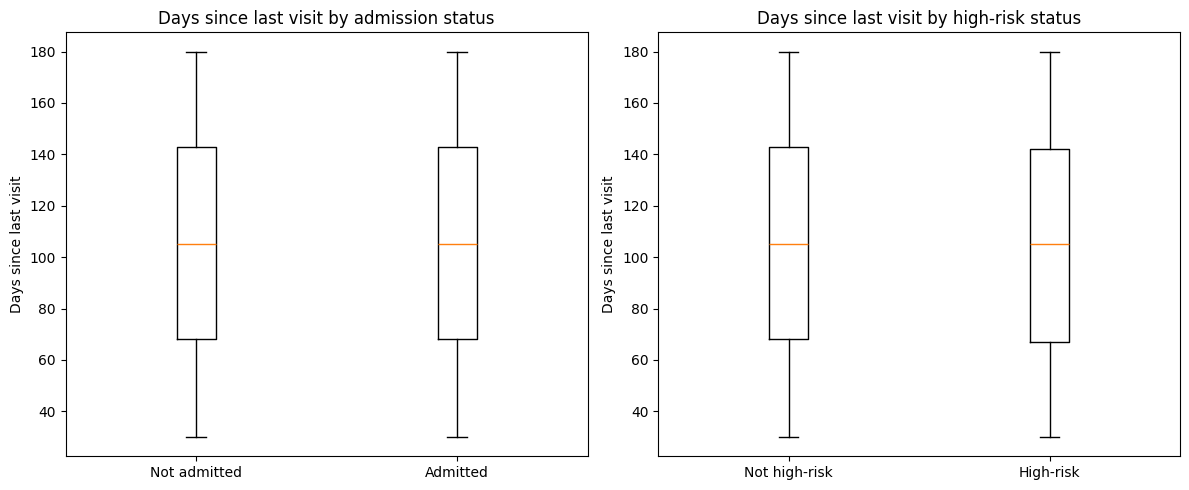

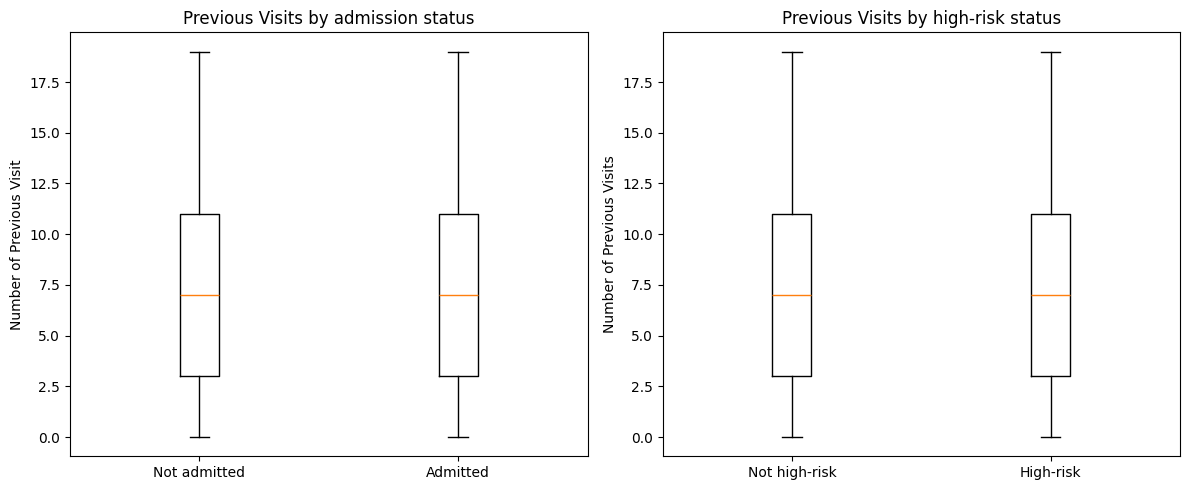

In [37]:
# Boxplots: days_since_last_visit by admitted_bin and high_risk
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#By admited_bin
data_adm = [
    df.loc[df['admitted_bin'] == 0, 'days_since_last_visit'].dropna(),
    df.loc[df['admitted_bin'] == 1, 'days_since_last_visit'].dropna()
]
axes[0].boxplot(data_adm, showfliers=False)
axes[0].set_xticklabels(['Not admitted', 'Admitted'])
axes[0].set_ylabel('Days since last visit')
axes[0].set_title('Days since last visit by admission status')

#By high_risk
data_hr = [
    df.loc[df['high_risk'] == 0, 'days_since_last_visit'].dropna(),
    df.loc[df['high_risk'] == 1, 'days_since_last_visit'].dropna()
]
axes[1].boxplot(data_hr, showfliers=False)
axes[1].set_xticklabels(['Not high-risk', 'High-risk'])
axes[1].set_ylabel('Days since last visit')
axes[1].set_title('Days since last visit by high-risk status')

plt.tight_layout()
plt.show()


#Boxplots: num_prev_visits by admitted_bin and high_risk
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

data_adm_visits = [
    df.loc[df['admitted_bin'] == 0, 'num_prev_visits'].dropna(),
    df.loc[df['admitted_bin'] == 1, 'num_prev_visits'].dropna()
]
axes[0].boxplot(data_adm_visits, showfliers=False)
axes[0].set_xticklabels(['Not admitted', 'Admitted'])
axes[0].set_ylabel('Number of Previous Visit')
axes[0].set_title('Previous Visits by admission status')

#By high_risk
data_hr_visits = [
    df.loc[df['high_risk'] == 0, 'num_prev_visits'].dropna(),
    df.loc[df['high_risk'] == 1, 'num_prev_visits'].dropna()
]
axes[1].boxplot(data_hr_visits, showfliers=False)
axes[1].set_xticklabels(['Not high-risk', 'High-risk'])
axes[1].set_ylabel('Number of Previous Visits')
axes[1].set_title('Previous Visits by high-risk status')

plt.tight_layout()
plt.show()

### Interpretation
When the time since last visit are compared, the distributions are almost identical between admitted vs not admitted and between high risk vs not high risk visits. Similarly, the number of previous visits looks very similar across all groups. this suggest that, in this engineered cohort, simple measures of how often patients attend or how recently they were seen are not strong drivers of either admissions decisions or the high-risk label. 


### Label Rates by Genotype


                admitted_bin  high_risk
genotype                               
HbSβ⁺               0.505209   0.586703
HbSC                0.501306   0.598792
HbSβ⁰ genotype      0.500271   0.597394
HbSS                0.495219   0.598215


<Figure size 1000x500 with 0 Axes>

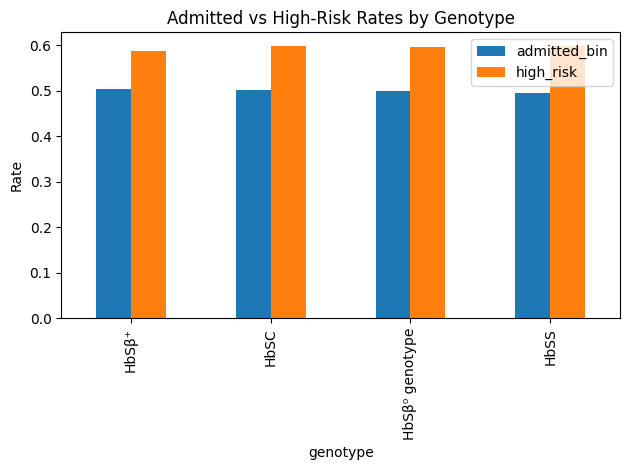

In [40]:
genotype_stats = df.groupby('genotype')[['admitted_bin', 'high_risk']].mean().dropna().sort_values('admitted_bin', ascending = False)
print(genotype_stats)

plt.figure(figsize=(10, 5))
genotype_stats[['admitted_bin', 'high_risk']].plot(kind='bar')
plt.ylabel('Rate')
plt.title('Admitted vs High-Risk Rates by Genotype')
plt.tight_layout()
plt.show()

### Interpretation
Break things down by sickle cell genotype, admission rates are almost identical across groups, all sitting very close to 50%. HbSβ⁺ has a slightly higher admission rate (~ 50.5%) and HbSS a slightly lower one (~ 49.5%), but the differnce are tiny. the high-risk rate is also very similar across genotypes (around 59-60%), with only small variation. Overall, this suggests that in this synthetic dataset, genotype on its own is not a strong  driver of either admission or high-risk status.


### Effect of Severity Keyword Flags on Label Rates


In [46]:
#severity_cols = ['has_severe', 'has_mild', 'has_worsening', 'has_shortness_of_breath']

#for col in severity_cols:
   # print(f"\n=== {col} ===")
   # print(df.groupby(col)[['admitted_bin', 'high_risk']].mean())

    #stats = df.groupby(col)[['admitted_bin', 'high_risk']].mean()

    #plt.figure(figsize=(6, 4))
    #stats[['admitted_bin', 'high_risk']].plot(kind='bar')
    #plt.title(f'Admitted vs High-Risk by {col}')
    #plt.tight_layout()
   # plt.show()

## Modelling with Text and Engineered Features
- Splitting the data by patient into train and test set
- Using TF-IDF on clean_notes_v2(text with numbers)
- Combining text features with the engineered numeric features
- Training and evaluating:
  
      - Logistic regression on: using both original target variable (admitted_bin) and engineered target (high_risk)
      - Multinomial Naive Bayes on text only (baseline)


In [4]:
#importing libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, roc_auc_score 
from scipy.sparse import hstack
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Patient-Level Train/Test Split


In [5]:
patients = df['patient_id'].unique()
train_p, test_p = train_test_split(patients, test_size=0.2, random_state = 42)

train_df = df[df['patient_id'].isin(train_p)].copy()
test_df = df[df['patient_id'].isin(test_p)].copy()
print('train rows:', len(train_df), 'Test row:', len(test_df))

train rows: 60029 Test row: 14987


### Interpretation
To avoid information leakage across repeated visits for the same patient, train-test split was done at patient level. First, unique patient_ids were randomly split into 80% train and 20% test, then all visits for those patients were assigned to the corresponding set. This resulted in 60,029 training visits and 14,987 test visits, with no patient overlapping between split.


### Defining Text and Numeric Features


In [6]:
text_col = 'clean_notes_v2'

numeric_features =[
    "years_since_diagnosis", "age_years",
    "num_prev_visits", "num_prev_admissions", "days_since_last_visit",
    "hemoglobin", "prev_hemoglobin", "delta_hemoglobin",
    "oxygen_saturation", "prev_oxygen_saturation", "delta_oxygen_saturation",
    "pain_intensity", 'has_severe', 'has_mild', 'has_worsening', 'has_shortness_of_breath'
]
# Fill Nans in numeric features
for col in numeric_features:
    train_df[col] = train_df[col].fillna(0)
    test_df[col] = test_df[col].fillna(0)

### TF-IDF Vectorisation and Numeric Feature Scaling


In [7]:
tfidf = TfidfVectorizer(max_features = 5000, ngram_range=(1, 2))
x_train_text = tfidf.fit_transform(train_df[text_col])
x_test_text = tfidf.transform(test_df[text_col])

#Scaling numeric features and combining with text
scaler = StandardScaler(with_mean = False)
x_train_num = scaler.fit_transform(train_df[numeric_features]) 
x_test_num = scaler.transform(test_df[numeric_features])

from scipy.sparse import csr_matrix
x_train = hstack([x_train_text, x_train_num])
x_test = hstack([x_test_text, x_test_num])

#Original Target
y_train_adm = train_df['admitted_bin'].values
y_test_adm = test_df['admitted_bin'].values

#Engineered Target
y_train_hr = train_df['high_risk'].values
y_test_hr = test_df['high_risk'].values

## Traditional Machine Learning Models


### Logistic Regression


In [8]:
logreg = LogisticRegression(max_iter = 200, n_jobs = -1)
logreg.fit(x_train, y_train_adm)

# Model for original target (admitted_bin)
y_pred_adm = logreg.predict(x_test)
y_proba_adm = logreg.predict_proba(x_test)[:, 1]

print('logist regeression: admitted_bin')
print(classification_report(y_test_adm, y_pred_adm))
print('ROC-AUC:', roc_auc_score(y_test_adm, y_proba_adm))

# Model for engineered target (high_risk)
logreg = LogisticRegression(max_iter = 200, n_jobs = -1)
logreg.fit(x_train, y_train_hr)


y_pred_hr = logreg.predict(x_test)
y_proba_hr = logreg.predict_proba(x_test)[:, 1]

print('logist regeression: high_risk')
print(classification_report(y_test_hr, y_pred_hr))
print('ROC-AUC:', roc_auc_score(y_test_hr, y_proba_hr))

logist regeression: admitted_bin
              precision    recall  f1-score   support

           0       0.50      0.46      0.48      7481
           1       0.50      0.54      0.52      7506

    accuracy                           0.50     14987
   macro avg       0.50      0.50      0.50     14987
weighted avg       0.50      0.50      0.50     14987

ROC-AUC: 0.4950588742569194
logist regeression: high_risk
              precision    recall  f1-score   support

           0       0.78      0.75      0.76      6053
           1       0.83      0.85      0.84      8934

    accuracy                           0.81     14987
   macro avg       0.81      0.80      0.80     14987
weighted avg       0.81      0.81      0.81     14987

ROC-AUC: 0.8962075578121194


### Interpretation
For the original admitted_bin outcome, logistic regression performs at random guess level (accuracy and ROC-AUC around 0.5). This suggest that, in this synthetic dataset, admission decisions are not strongly determined by the available clinical features and notes, and likely depend on factors not available in the dataset or policy rules.

For the engineered high_risk label, the logistic regression model performs substantially better, achieving 81% accuracy and an F1 score of 0.84 and a ROC-AUC of 0.90 for the high-risk class. The model shows good balance between precision (0.83) and recall (0.85) for high-risk visits, with a macro F1 of 0.80. this is expected because high_risk is explicitly definedfrom hemoglobin, oxygen saturation and pain intensity, which are all included as features.


### Linear Support Vector Machine


In [9]:
# Model for original text (admitted_bin)

svm_adm = LinearSVC(random_state = 42)
svm_adm.fit(x_train, y_train_adm)

y_pred_svm_adm = svm_adm.predict(x_test)
# decision_function for a continous score for ROC-AUC
y_scores_svm_adm = svm_adm.decision_function(x_test)

print('Linear SVM: admitted_bin')
print(classification_report(y_test_adm, y_pred_svm_adm))
print('ROC-AUC:', roc_auc_score(y_test_adm, y_scores_svm_adm))

#Model for engineered target(high_risk)
svm_hr = LinearSVC(random_state = 42)
svm_hr.fit(x_train, y_train_hr)

y_pred_svm_hr = svm_hr.predict(x_test)
# decision_function for a continous score for ROC-AUC
y_scores_svm_hr = svm_hr.decision_function(x_test)

print('Linear SVM: high_risk')
print(classification_report(y_test_hr, y_pred_svm_hr))
print('ROC-AUC:', roc_auc_score(y_test_hr, y_scores_svm_hr))

Linear SVM: admitted_bin
              precision    recall  f1-score   support

           0       0.50      0.46      0.48      7481
           1       0.50      0.54      0.52      7506

    accuracy                           0.50     14987
   macro avg       0.50      0.50      0.50     14987
weighted avg       0.50      0.50      0.50     14987

ROC-AUC: 0.4954552777151802
Linear SVM: high_risk
              precision    recall  f1-score   support

           0       0.78      0.75      0.76      6053
           1       0.83      0.85      0.84      8934

    accuracy                           0.81     14987
   macro avg       0.80      0.80      0.80     14987
weighted avg       0.81      0.81      0.81     14987

ROC-AUC: 0.8962534364105798


### Interpretation
Both linear SVM and logistic regression fail to predict admitted_bin better than a random guess. Suggesting that the admission decision in this synthetic dataset depend on factors not originally captured in the notes, vitals, or engineered features.

For the engineered high_risk outcome, linear SVM achieves 81% accuracy, macro F1 of 0.80 an ROC_AUC of 0.90, virtually matching the performance of logistic regression. This indicates that both linear models effectively exploits the combination of TF-IDF clinical notes and structured features to identify high-risk visits.


## Traditional Model Evaluation


### Confusion Matrices


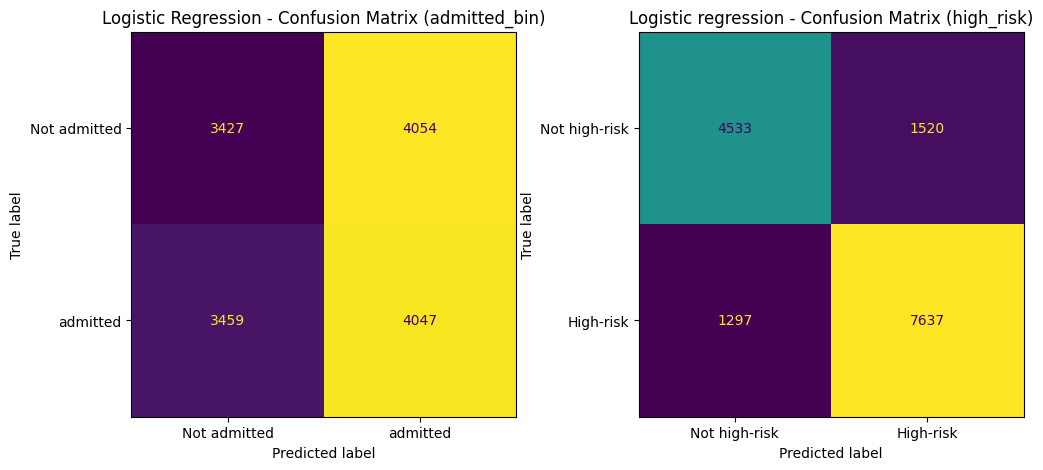

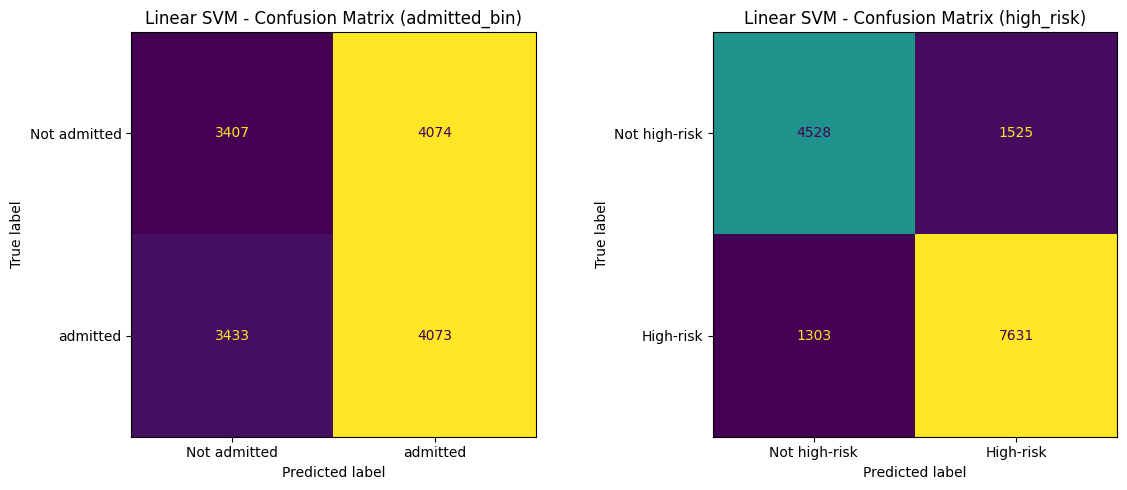

In [80]:
#Logistic regression 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# admitted_bin
cm_adm_lr = confusion_matrix(y_test_adm, y_pred_adm)
disp_adm_lr = ConfusionMatrixDisplay(
    confusion_matrix = cm_adm_lr,
    display_labels = ["Not admitted", "admitted"]
)
disp_adm_lr.plot(ax = axes[0], values_format = 'd', colorbar = False)
axes[0].set_title("Logistic Regression - Confusion Matrix (admitted_bin)")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

# High_risk
cm_hr_lr = confusion_matrix(y_test_hr, y_pred_hr)
disp_hr_lr = ConfusionMatrixDisplay(
    confusion_matrix = cm_hr_lr,
    display_labels= ["Not high-risk", "High-risk"]
)
disp_hr_lr.plot(ax = axes[1], values_format = 'd', colorbar = False)
axes[1].set_title("Logistic regression - Confusion Matrix (high_risk)")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")



#Linear SVM

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# admitted_bin
cm_adm_svm = confusion_matrix(y_test_adm, y_pred_svm_adm)
disp_adm_svm = ConfusionMatrixDisplay(
    confusion_matrix = cm_adm_svm,
    display_labels = ["Not admitted", "admitted"]
)
disp_adm_svm.plot(ax = axes[0], values_format = 'd', colorbar = False)
axes[0].set_title("Linear SVM - Confusion Matrix (admitted_bin)")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

# High_risk
cm_hr_svm = confusion_matrix(y_test_hr, y_pred_svm_hr)
disp_hr_svm = ConfusionMatrixDisplay(
    confusion_matrix = cm_hr_svm,
    display_labels= ["Not high-risk", "High-risk"]
)
disp_hr_svm.plot(ax = axes[1], values_format = 'd', colorbar = False)
axes[1].set_title("Linear SVM - Confusion Matrix (high_risk)")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

plt.tight_layout()
plt.show()

### Interpretation
For the original admitted_bin label, both logistic regression and linera SVM performed poorly. Accuracy was around 50% with ROC-AUC close to 0.5. meaning the models were just guessing and could not reliably predict admission decisions. In contrast, performance on the engineered high_risk label was much stronger, with both models reaching about 81% accuracy and a ROC-AUC near 0.90. They correctly identified most high-risk visits, at the cost of flagging some low-risk visits as high-risk. Logistic regression and linear SVM behaved very similar overall, with only a little edge in favour of the SVM.  


### ROC Curves


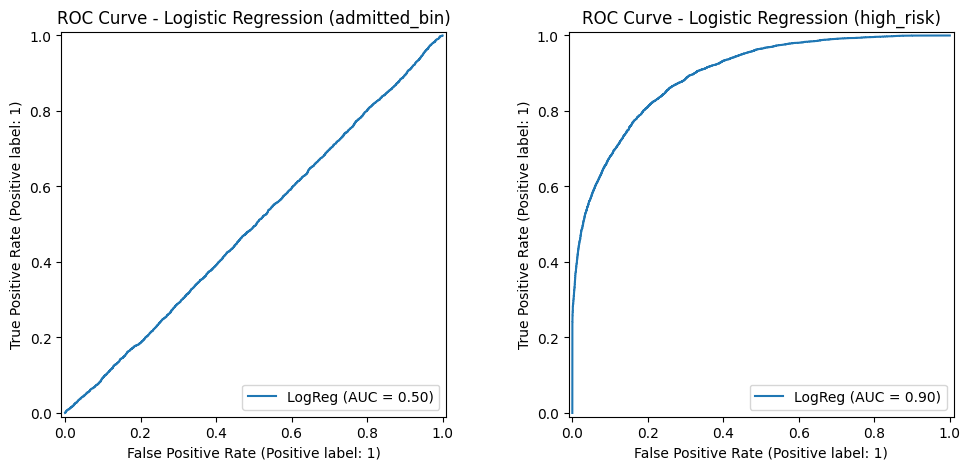

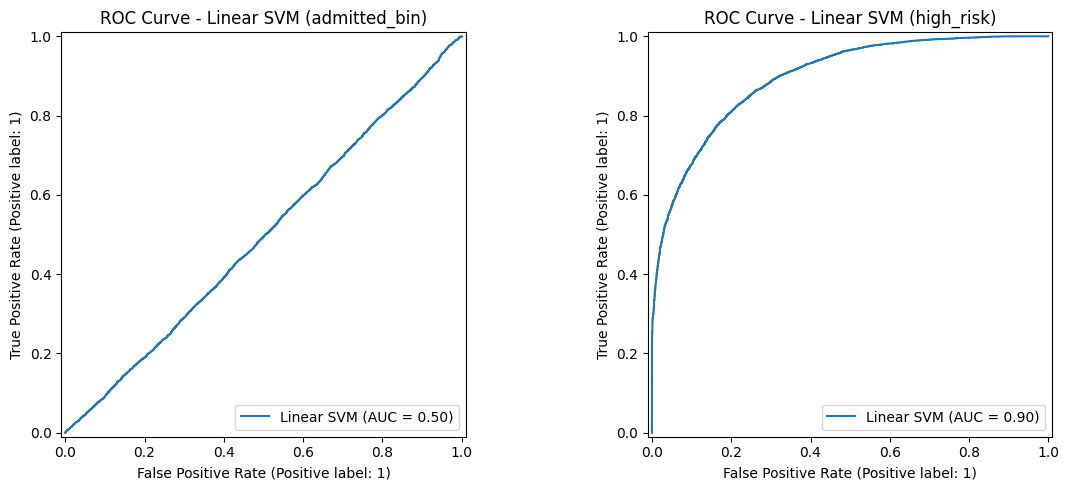

In [82]:
from sklearn.metrics import RocCurveDisplay

# Logistic Regression

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Admitted bin
RocCurveDisplay.from_predictions(
    y_test_adm, y_proba_adm, ax = axes[0], name = "LogReg"
)
axes[0].set_title("ROC Curve - Logistic Regression (admitted_bin)")

# high risk
RocCurveDisplay.from_predictions(
    y_test_hr, y_proba_hr, ax = axes[1], name = "LogReg"
)
axes[1].set_title("ROC Curve - Logistic Regression (high_risk)")




# Linear SVM

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Admitted bin
RocCurveDisplay.from_predictions(
    y_test_adm, y_scores_svm_adm, ax = axes[0], name = "Linear SVM"
)
axes[0].set_title("ROC Curve - Linear SVM (admitted_bin)")

# high risk
RocCurveDisplay.from_predictions(
    y_test_hr, y_scores_svm_hr, ax = axes[1], name = "Linear SVM"
)
axes[1].set_title("ROC Curve - Linear SVM (high_risk)")

plt.tight_layout()
plt.show()

### Interpretation
For the admitted_bin label, both Logistic Regression and Linera SVM have ROC curves that sit almost on the 45 degrees diagonal, with AUC approximately 0.50. Again, the models are no better than random guessing at predicting whether a visit ends in admission.

For the high_risk label, the picture is completely different. Both models show steep ROC curves that stay high above the diagonal, with AUC around 0.90. This indicates very strong discrimination between high-risk and not-high-risk visits. in other words, once target is redifined to capture clinical risk (low Hb, low oxygen saturation, high pain), the same models become highly effective at ranking which visits are truly high risk.


## Hyperparameter Tuning


### Logistic Regression Tuning


In [10]:
from sklearn.model_selection import GridSearchCV

logreg_tuned = LogisticRegression(max_iter=200, n_jobs=-1, 
                                  solver="liblinear"
)

param_grid_lr = {"C": [0.1, 1.0, 10.0],
                 "class_weight": [None, "balanced"],
    
}

def tune_logreg(x_train, y_train, x_test, y_test, label_name):
    print(f"Logistic Regression tuning for {label_name}")

    grid_lr = GridSearchCV(estimator=logreg_tuned, param_grid=param_grid_lr, cv=3,
                       scoring="roc_auc", n_jobs=-1, verbose=1
    )

    grid_lr.fit(x_train, y_train)
    print("Best params (LogReg, admitted_bin):", grid_lr.best_params_)
    print("Best CV ROC-AUC:", grid_lr.best_score_)

    best_lr = grid_lr.best_estimator_
    y_pred = best_lr.predict(x_test)
    y_proba = best_lr.predict_proba(x_test)[:, 1]

    print(f"\nTuned Logistic Regression ({label_name}) - test set")
    print(classification_report(y_test, y_pred))
    print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))

    return best_lr, y_pred, y_proba

# Tune for admitted_bin
best_lr_adm, y_pred_adm_tuned, y_proba_adm_tuned = tune_logreg(
    x_train, y_train_adm, x_test, y_test_adm, "admitted_bin" 
)

# Tune for high_risk
best_lr_hr, y_pred_hr_tuned, y_proba_hr_tuned = tune_logreg(
    x_train, y_train_hr, x_test, y_test_hr, "high_risk" 
)

Logistic Regression tuning for admitted_bin
Fitting 3 folds for each of 6 candidates, totalling 18 fits


C:\Program Files\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 24.
  warnings.warn(


Best params (LogReg, admitted_bin): {'C': 10.0, 'class_weight': None}
Best CV ROC-AUC: 0.4966933315767356

Tuned Logistic Regression (admitted_bin) - test set
              precision    recall  f1-score   support

           0       0.50      0.46      0.48      7481
           1       0.50      0.54      0.52      7506

    accuracy                           0.50     14987
   macro avg       0.50      0.50      0.50     14987
weighted avg       0.50      0.50      0.50     14987

Test ROC-AUC: 0.49546122581505264
Logistic Regression tuning for high_risk
Fitting 3 folds for each of 6 candidates, totalling 18 fits


C:\Program Files\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 24.
  warnings.warn(


Best params (LogReg, admitted_bin): {'C': 1.0, 'class_weight': 'balanced'}
Best CV ROC-AUC: 0.8990062129012539

Tuned Logistic Regression (high_risk) - test set
              precision    recall  f1-score   support

           0       0.73      0.81      0.77      6053
           1       0.86      0.80      0.83      8934

    accuracy                           0.80     14987
   macro avg       0.80      0.81      0.80     14987
weighted avg       0.81      0.80      0.81     14987

Test ROC-AUC: 0.8963161057254456


### Interpretation
Hyperparameter tuning was done for the logistic regression models by varying the regularisation strength ("C" = 0.1, 1.0, and 10.0) and class weigh (None and "balanced"), using ROC-AUC as the CV metric. For the admitted bin label, the tuned model (c=10.0, and class weigh = None) yeilded no improvement with an ROC-AUC and accuracy almost 0.50, respectively,  confirming that admission is not learnable from the available features.

In contrast, for the high risk label, tunning "C" and class weight selected a model with  C = 1.0 and class weigh = "balanced", which maintained strong performance (test ROC-AUC almost 0.90 and accuracy almost 0.80), but only marginally improved over the untuned logistic regression. This suggests that the engineered high_risk target is learnable from the features, and that the default model was already close to optimal, with tunning mainly confirming its robustness rather than yielding a large performance. 


### Linear SVM Tuning


In [11]:
svm_tuned = LinearSVC(random_state = 42)

param_grid_svm = {"C": [0.1, 1.0, 10.0],
                 "class_weight": [None, "balanced"],
    
}

def tune_svm(x_train, y_train, x_test, y_test, label_name):
    print(f"Linear SVM tuning for {label_name}")

    grid_svm = GridSearchCV(estimator=svm_tuned, param_grid=param_grid_svm, cv=3,
                       scoring="roc_auc", n_jobs=-1, verbose=1
    )

    grid_svm.fit(x_train, y_train)
    print("Best params (LinearSVM, admitted_bin):", grid_svm.best_params_)
    print("Best CV ROC-AUC:", grid_svm.best_score_)

    best_svm = grid_svm.best_estimator_
    y_pred = best_svm.predict(x_test)
    y_scores = best_svm.decision_function(x_test)

    print(f"\nTuned Linear SVM ({label_name}) - test set")
    print(classification_report(y_test, y_pred))
    print("Test ROC-AUC:", roc_auc_score(y_test, y_scores))

    return best_svm, y_pred, y_scores

# Tune for admitted_bin
best_svm_adm, y_pred_svm_adm_tuned, y_scores_svm_adm_tuned = tune_svm(
    x_train, y_train_adm, x_test, y_test_adm, "admitted_bin" 
)

# Tune for high_risk
best_svm_hr, y_pred_svm_hr_tuned, y_scores_svm_hr_tuned = tune_svm(
    x_train, y_train_hr, x_test, y_test_hr, "high_risk" 
)

Linear SVM tuning for admitted_bin
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params (LinearSVM, admitted_bin): {'C': 10.0, 'class_weight': None}
Best CV ROC-AUC: 0.4970321366835541

Tuned Linear SVM (admitted_bin) - test set
              precision    recall  f1-score   support

           0       0.50      0.46      0.48      7481
           1       0.50      0.54      0.52      7506

    accuracy                           0.50     14987
   macro avg       0.50      0.50      0.50     14987
weighted avg       0.50      0.50      0.50     14987

Test ROC-AUC: 0.4958536757458535
Linear SVM tuning for high_risk
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params (LinearSVM, admitted_bin): {'C': 0.1, 'class_weight': 'balanced'}
Best CV ROC-AUC: 0.899014256326168

Tuned Linear SVM (high_risk) - test set
              precision    recall  f1-score   support

           0       0.73      0.81      0.77      6053
           1       0.86      0.80    

### Interpretation
For the admitted bin label, tuning the Linear SVM (best: C = 10.0, class_weight = None) did not improve performance. The test accuracy stayed around 0.50, indicating the model was still performing at a guess level.

In contrast, for the high_risk label, the tuned Linear SVM (best: C = 0.1, class_weight="balanced") schieved strong performance, with test accuracy almost 0.80 and ROC-AUC almmost 0.90. This mirrors the Logistic Regression results and reinforces that the engineered high_risk outcomes carries a much clearer and more learnable signal than the original admission label.


### Metrics Summary for Base and Tuned Models


In [12]:
def collect_metrics(y_true, y_pred, y_score, model_name, label_name):
    return {
        "Model": model_name,
        "Label": label_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_score),
    }

rows = []
# Base Models
# Logistic Regression
rows.append(collect_metrics(y_test_adm, y_pred_adm,   y_proba_adm,   "LogReg",   "admitted_bin"))
rows.append(collect_metrics(y_test_hr, y_pred_hr,   y_proba_hr,   "LogReg",   "high_risk"))

# Linear SVM
rows.append(collect_metrics(y_test_adm, y_pred_svm_adm,   y_scores_svm_adm,   "LinearSVM",   "admitted_bin"))
rows.append(collect_metrics(y_test_hr, y_pred_svm_hr,   y_scores_svm_hr,   "LinearSVM",   "high_risk"))



# Tuned Models
# Logistic Regression
rows.append(collect_metrics(y_test_adm, y_pred_adm_tuned,   y_proba_adm_tuned,   "LogReg (tuned)",   "admitted_bin"))
rows.append(collect_metrics(y_test_hr, y_pred_hr_tuned,   y_proba_hr_tuned,   "LogReg (tuned)",   "high_risk"))

# Linear SVM
rows.append(collect_metrics(y_test_adm, y_pred_svm_adm_tuned,   y_scores_svm_adm_tuned,   "LinearSVM (tuned)",   "admitted_bin"))
rows.append(collect_metrics(y_test_hr, y_pred_svm_hr_tuned,   y_scores_svm_hr_tuned,   "LinearSVM (tuned)",   "high_risk"))

metrics_df = pd.DataFrame(rows)
display(metrics_df.round(3))

,Model,Label,Accuracy,Precision,Recall,ROC_AUC
0,LogReg,admitted_bin,0.499,0.500,0.539,0.495
1,LogReg,high_risk,0.812,0.834,0.855,0.896
2,LinearSVM,admitted_bin,0.499,0.500,0.543,0.495
3,LinearSVM,high_risk,0.811,0.833,0.854,0.896
4,LogReg (tuned),admitted_bin,0.499,0.500,0.542,0.495
5,LogReg (tuned),high_risk,0.805,0.863,0.799,0.896
6,LinearSVM (tuned),admitted_bin,0.499,0.500,0.540,0.496
7,LinearSVM (tuned),high_risk,0.804,0.862,0.798,0.896


### Interpretation
Accross all configurations, admission prediction(admitted_bin) remained essentially at chance level, with accuracy and ROC-AUC close to 0.50 for both Logistic Regression and Linear SVM, even after hyperparameter tuning.

In contrast, for the high risk label, all models achieved consistently strong performance with accuracy around 0.80 - 0.81 and ROC-AUC almost 0.90.

Tuning mainly produced a small trade-off between recall and precision for high_risk (e.g. slightly higher precision in the tuned models at the cost of a modest drop in recall), rather than a large jump in overall performance.

This pattern reinforces that the engineered high_risk outcome is much more learnable from the available features than the original admission label.


## Deep Learning Models


### LSTM Model
building first, a hybrid LSTM (text and numeric features.


In [13]:
# Importing Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, LSTM, Bidirectional, BatchNormalization, Dense, Dropout, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

### Preparing Data for the Hybrid LSTM
Note: y_train_adm, y_test_adm, y_train_hr and y_test_hr have been prepared (before the setups of the traditional model). numeric features have been scaled already as well.


In [14]:
# Tokenizing & padding text.
x_train_text = train_df[text_col].astype(str).values
x_test_text = test_df[text_col].astype(str).values

max_words = 20000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token="<oov>")
tokenizer.fit_on_texts(x_train_text)

x_train_seq = tokenizer.texts_to_sequences(x_train_text)
x_test_seq = tokenizer.texts_to_sequences(x_test_text)

x_train_pad = pad_sequences(x_train_seq, maxlen=max_len, padding='post',truncating="post")
x_test_pad = pad_sequences(x_test_seq, maxlen=max_len, padding='post',truncating="post")

print("Text shapes:", x_train_pad.shape, x_test_pad.shape)
print("Numeric shapes:", x_train_num.shape, x_test_num.shape)

Text shapes: (60029, 200) (14987, 200)
Numeric shapes: (60029, 16) (14987, 16)


### Base Hybrid LSTM


In [15]:
embedding_dim = 128
num_numeric = x_train_num.shape[1]

def build_hybrid_lstm_base():
    # Text input branch
    text_input = Input(shape=(max_len,), name="text_input")
    x = Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len)(text_input)
    x = Bidirectional(LSTM(64))(x)
    x = Dropout(0.5)(x)

    # Numeric input branch
    num_input = Input(shape=(num_numeric,), name="num_input")
    n = Dense(32, activation = "relu")(num_input)
    n = Dropout(0.3)(n)

    # combining
    combined = Concatenate()([x, n])
    combined = Dense(64, activation="relu")(combined)
    combined = Dropout(0.5)(combined)
    output = Dense(1, activation = "sigmoid")(combined)

    model = Model(inputs=[text_input, num_input], outputs=output)
    model.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate=1e-3), metrics=["accuracy"])
    return model

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

batch_size = 128
epochs = 8

    

### Training and Evaluating Hybrid LSTM: Admission Target


In [16]:
print("Hybrid LSTM (base) for admitted_bin")
hybrid_lstm_adm = build_hybrid_lstm_base()

history_adm = hybrid_lstm_adm.fit({"text_input": x_train_pad, "num_input": x_train_num},
                                 y_train_adm, validation_split=0.1, epochs=epochs, batch_size=batch_size,
                                 callbacks = [early_stop], verbose=1)
y_proba_adm_lstm = hybrid_lstm_adm.predict({"text_input": x_test_pad, "num_input": x_test_num}).ravel()
y_pred_adm_lstm = (y_proba_adm_lstm >= 0.5).astype(int)

print("\nHybrid LSTM (base) - admitted_bin")
print(classification_report(y_test_adm, y_pred_adm_lstm))
print("ROC-AUC:", roc_auc_score(y_test_adm, y_proba_adm_lstm))

Hybrid LSTM (base) for admitted_bin


C:\Program Files\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 124s 287ms/step - accuracy: 0.4982 - loss: 0.7949 - val_accuracy: 0.5017 - val_loss: 0.6931
Epoch 2/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 150s 304ms/step - accuracy: 0.4996 - loss: 0.6934 - val_accuracy: 0.4984 - val_loss: 0.6932
Epoch 3/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 143s 306ms/step - accuracy: 0.5004 - loss: 0.6934 - val_accuracy: 0.4984 - val_loss: 0.6931
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step

Hybrid LSTM (base) - admitted_bin
              precision    recall  f1-score   support

           0       0.50      0.03      0.05      7481
           1       0.50      0.97      0.66      7506

    accuracy                           0.50     14987
   macro avg       0.50      0.50      0.35     14987
weighted avg       0.50      0.50      0.36     14987

ROC-AUC: 0.5006537834385167


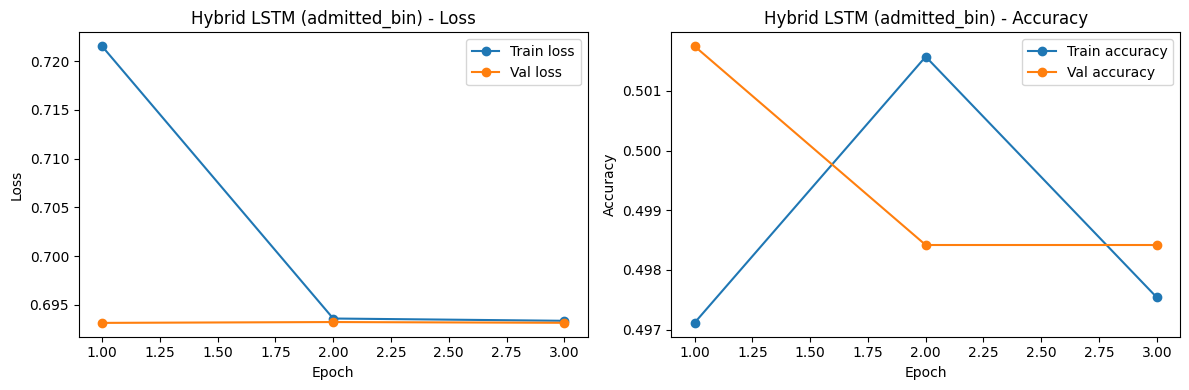

In [17]:
import matplotlib.pyplot as plt

def plot_training_curves(history, title_prefix = "Hybrid LSTM (base)"):
    # Extract metrics from history
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    train_acc = history.history.get("accuracy")
    val_acc = history.history.get("val_accuracy")
    epochs_range = range(1, len(train_loss) + 1)

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_loss, marker="o", label="Train loss")
    plt.plot(epochs_range, val_loss, marker="o", label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.legend()

    # Accuracy
    if train_acc is not None and val_acc is not None:
        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, train_acc, marker="o", label="Train accuracy")
        plt.plot(epochs_range, val_acc, marker="o", label="Val accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(f"{title_prefix} - Accuracy")
        plt.legend()

    plt.tight_layout()
    plt.show()

# Plotting for admitted_bin LSTM
plot_training_curves(history_adm, title_prefix="Hybrid LSTM (admitted_bin)")

### Interpretation
The base hybrid LSTM model for the admitted label converged to a random guess (with accuracy almost 0.50, ROC-AUC also almost 0.50), effectively predicting all visits as "not admitted". This mirrors the traditional models and suggests that, in this synthetic dataset, admission status is not learnably encoded in the available features. The loss and accuracy plot above confirms this.


### Training and Evaluating Hybrid LSTM: High-Risk Target


In [18]:
print("Hybrid LSTM (base) for high_risk")
hybrid_lstm_hr = build_hybrid_lstm_base()

history_hr = hybrid_lstm_hr.fit({"text_input": x_train_pad, "num_input": x_train_num},
                                 y_train_hr, validation_split=0.1, epochs=epochs, batch_size=batch_size,
                                 callbacks = [early_stop], verbose=1)
y_proba_hr_lstm = hybrid_lstm_hr.predict({"text_input": x_test_pad, "num_input": x_test_num}).ravel()
y_pred_hr_lstm = (y_proba_hr_lstm >= 0.5).astype(int)

print("\nHybrid LSTM (base) - high_risk")
print(classification_report(y_test_hr, y_pred_hr_lstm))
print("ROC-AUC:", roc_auc_score(y_test_hr, y_proba_hr_lstm))

Hybrid LSTM (base) for high_risk
Epoch 1/8


C:\Program Files\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


423/423 ━━━━━━━━━━━━━━━━━━━━ 124s 286ms/step - accuracy: 0.6026 - loss: 0.7361 - val_accuracy: 0.8011 - val_loss: 0.4451
Epoch 2/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 142s 286ms/step - accuracy: 0.7915 - loss: 0.4488 - val_accuracy: 0.8749 - val_loss: 0.2871
Epoch 3/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 144s 290ms/step - accuracy: 0.8532 - loss: 0.3261 - val_accuracy: 0.8997 - val_loss: 0.2431
Epoch 4/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 146s 301ms/step - accuracy: 0.8721 - loss: 0.2861 - val_accuracy: 0.8999 - val_loss: 0.2304
Epoch 5/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 143s 303ms/step - accuracy: 0.8820 - loss: 0.2664 - val_accuracy: 0.9102 - val_loss: 0.2173
Epoch 6/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 141s 301ms/step - accuracy: 0.8884 - loss: 0.2529 - val_accuracy: 0.9125 - val_loss: 0.2104
Epoch 7/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 143s 303ms/step - accuracy: 0.8924 - loss: 0.2483 - val_accuracy: 0.9152 - val_loss: 0.2058
Epoch 8/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 134s 316ms/step - accuracy: 0.8939 - loss: 0.2420 - va

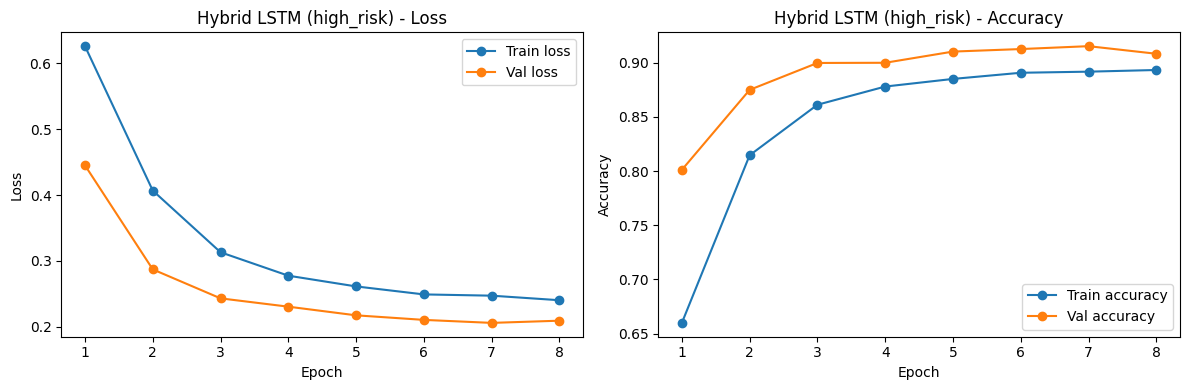

In [19]:
# Plotting for high_risk LSTM
plot_training_curves(history_hr, title_prefix="Hybrid LSTM (high_risk)")

### Interpretation
The hybrid LSTM (clinical text plus numeric features) showed clear learning for the high_risk outcome. Training loss fell from 0.7361 to 0.2420 and validation loss from 0.4451 to 0.2091, while accuracy improved from 0.6026 to 0.8939 (train) and 0.8011 to 0.9082 (validation) over 8 epochs without clear overfitting.  On the test set, accuracy reached 0.92 with ROC-AUC 0.9732, and class 1 (high risk) achieved precision 0.96, recall 0.90, and F1-score 0.93. This clearly outperforms the logistic regression and SVM baselines (ROC-AUC almost 0.90), suggesting that the LSTM is capturing additional temporal/sequential signal in the notes.


### ROC Curves for Hybrid LSTM


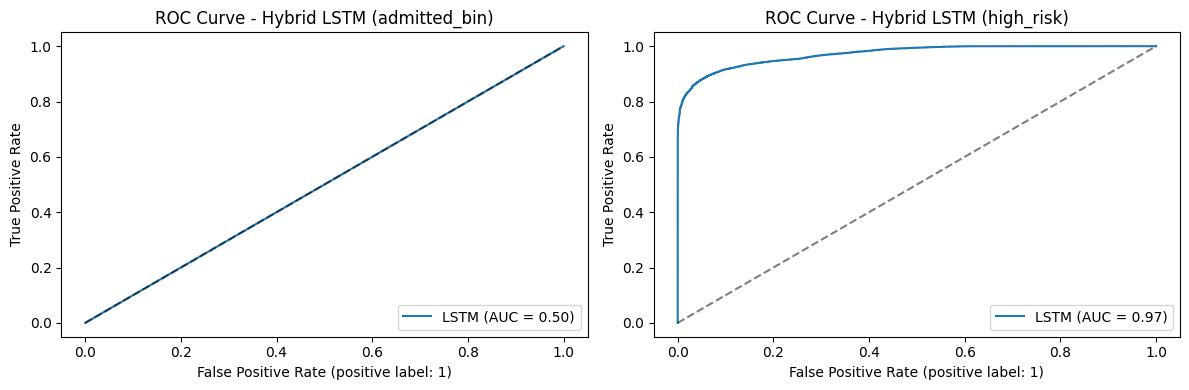

AUC (admitted_bin, LSTM): 0.5
AUC (high_risk, LSTM): 0.9716034775422872


In [41]:
from sklearn.metrics import roc_curve, roc_auc_score

#AUC values
auc_adm_lstm = roc_auc_score(y_test_adm, y_proba_adm_lstm)
auc_hr_lstm = roc_auc_score(y_test_hr, y_proba_hr_lstm)

fpr_adm, tpr_adm, _ = roc_curve(y_test_adm, y_proba_adm_lstm)
fpr_hr, tpr_hr, _ = roc_curve(y_test_hr, y_proba_hr_lstm)

plt.figure(figsize=(12, 4))

# admitted_bin
plt.subplot(1, 2, 1)
plt.plot(fpr_adm, tpr_adm, label=f"LSTM (AUC = {auc_adm_lstm:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate (positive label: 1)")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hybrid LSTM (admitted_bin)")
plt.legend(loc="lower right")

# high_risk
plt.subplot(1, 2, 2)
plt.plot(fpr_hr, tpr_hr, label=f"LSTM (AUC = {auc_hr_lstm:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate (positive label: 1)")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hybrid LSTM (high_risk)")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

print("AUC (admitted_bin, LSTM):", auc_adm_lstm)
print("AUC (high_risk, LSTM):", auc_hr_lstm)

### Interpretation
For admitted_bin, the hybrid LSTM lies almost exactly o the ROC diagonal (AUC almost 0.50), indicating that even a relatively expressive deep model cannot extract a reliable signal for admission decisions from this synthetic dataset. In contrast , for the high_risk label the same architecture performs very strongly (AUC almost 0.97, accuracy almost 0.90), showinh that the engineered high_risk definition is highly learnable and that combining clinical notes with numeric features enables the model to separate high risk from non-high-risk vists very well.


## Refined Hybrid LSTM Architecture

- Stack two BiLSTM layers,
- Batch Normalization + L2 regularisation on dense layers,
- Slightly lower dropout and a smaller learning rate


In [20]:
from tensorflow.keras.regularizers import l2


embedding_dim = 128
num_numeric = x_train_num.shape[1]

def build_hybrid_lstm_refined():
    # Text
    text_input = Input(shape=(max_len,), name="text_input")
    x = Embedding(input_dim=max_words, output_dim=embedding_dim)(text_input)
    # two-layer BiLSTM for richer sequencingmodelling
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Bidirectional(LSTM(32))(x)
    x = Dropout(0.4)(x)

    # Numeric
    num_input = Input(shape=(num_numeric,), name="num_input")
    n = Dense(64, activation="relu", kernel_regularizer=l2(1e-4))(num_input)
    n = BatchNormalization()(n)
    n = Dropout(0.3)(n)
    n = Dense(32, activation="relu", kernel_regularizer=l2(1e-4))(n)

    # Combining Text and Numeric
    combined = Concatenate()([x, n])
    combined = Dense(64, activation="relu", kernel_regularizer=l2(1e-4))(combined)
    combined = BatchNormalization()(combined)
    combined = Dropout(0.4)(combined)
    combined = Dense(32, activation="relu", kernel_regularizer=l2(1e-4))(combined)

    output = Dense(1, activation="sigmoid")(combined)

    model = Model(inputs=[text_input, num_input], outputs=output)
    model.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate=2e-4), metrics=["accuracy"])
    return model

early_stop_ref = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

batch_size_ref = 128
epochs_ref = 12

### Training and Evaluating Refined LSTM: Admission Target


In [21]:
print("Refined Hybrid LSTM for admitted_bin")

lstm_ref_adm = build_hybrid_lstm_refined()

history_adm_ref = lstm_ref_adm.fit({"text_input": x_train_pad, "num_input": x_train_num}, y_train_adm,
                                   validation_split=0.1, epochs=epochs_ref, batch_size=batch_size_ref,
                                   callbacks=[early_stop_ref], verbose=1)

y_proba_adm_lstm_ref = lstm_ref_adm.predict({"text_input": x_test_pad, "num_input": x_test_num}).ravel()
y_pred_adm_lstm_ref = (y_proba_adm_lstm_ref >= 0.5).astype(int)

print("\nRefined Hybrid LSTM - admitted_bin")
print(classification_report(y_test_adm, y_pred_adm_lstm_ref))
print("ROC-AUC:", roc_auc_score(y_test_adm, y_proba_adm_lstm_ref))

Refined Hybrid LSTM for admitted_bin
Epoch 1/12
423/423 ━━━━━━━━━━━━━━━━━━━━ 330s 765ms/step - accuracy: 0.5038 - loss: 0.7943 - val_accuracy: 0.4944 - val_loss: 0.7143
Epoch 2/12
423/423 ━━━━━━━━━━━━━━━━━━━━ 293s 692ms/step - accuracy: 0.4998 - loss: 0.7379 - val_accuracy: 0.4951 - val_loss: 0.7140
Epoch 3/12
423/423 ━━━━━━━━━━━━━━━━━━━━ 308s 659ms/step - accuracy: 0.5034 - loss: 0.7247 - val_accuracy: 0.4821 - val_loss: 0.7154
Epoch 4/12
423/423 ━━━━━━━━━━━━━━━━━━━━ 321s 657ms/step - accuracy: 0.4994 - loss: 0.7217 - val_accuracy: 0.4893 - val_loss: 0.7113
Epoch 5/12
423/423 ━━━━━━━━━━━━━━━━━━━━ 319s 650ms/step - accuracy: 0.4991 - loss: 0.7186 - val_accuracy: 0.4981 - val_loss: 0.7094
Epoch 6/12
423/423 ━━━━━━━━━━━━━━━━━━━━ 325s 657ms/step - accuracy: 0.4979 - loss: 0.7158 - val_accuracy: 0.4866 - val_loss: 0.7105
Epoch 7/12
423/423 ━━━━━━━━━━━━━━━━━━━━ 280s 557ms/step - accuracy: 0.5062 - loss: 0.7119 - val_accuracy: 0.4888 - val_loss: 0.7084
Epoch 8/12
423/423 ━━━━━━━━━━━━━━━━━━━━

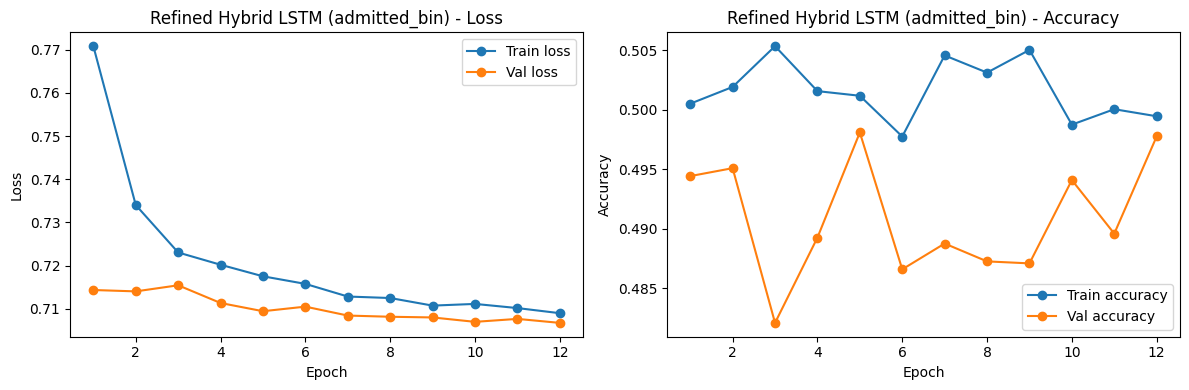

In [22]:
# Plotting for admitted_bin LSTM
plot_training_curves(history_adm_ref, title_prefix="Refined Hybrid LSTM (admitted_bin)")

### Interpretation
For admitted_bin label, even the refined hybrid LSTM still performs at a random guess level. Training accuracy stayed around 0.50 (0.4979–0.5071) and validation accuracy fluctuated between 0.4821 and 0.4981, with minimal loss reduction (train: 0.7943 to 0.7087, val: 0.7143 to 0.7067). On the test set, accuracy was 0.50 and ROC-AUC 0.5004, indicating no discriminative power. The model mostly predicts the positive class, leading leading to high recall for admissions but poor precision and very week performance on the non-admitted class. This still suggest that there is no stable, learnable signal for admission status, even with a deeper BiLSTM, batch normalisation, L2 regularisation, and a reduced learning. 


### Training and Evaluating Refined LSTM: High-Risk Target


In [24]:
print("Refined Hybrid LSTM for high_risk")

lstm_ref_hr = build_hybrid_lstm_refined()

history_hr_ref = lstm_ref_hr.fit({"text_input": x_train_pad, "num_input": x_train_num}, y_train_hr,
                                   validation_split=0.1, epochs=epochs_ref, batch_size=batch_size_ref,
                                   callbacks=[early_stop_ref], verbose=1)

y_proba_hr_lstm_ref = lstm_ref_hr.predict({"text_input": x_test_pad, "num_input": x_test_num}).ravel()
y_pred_hr_lstm_ref = (y_proba_hr_lstm_ref >= 0.5).astype(int)

print("\nRefined Hybrid LSTM - high_risk")
print(classification_report(y_test_hr, y_pred_hr_lstm_ref))
print("ROC-AUC:", roc_auc_score(y_test_hr, y_proba_hr_lstm_ref))

Refined Hybrid LSTM for high_risk
Epoch 1/12
423/423 ━━━━━━━━━━━━━━━━━━━━ 243s 561ms/step - accuracy: 0.6611 - loss: 0.6444 - val_accuracy: 0.7924 - val_loss: 0.4462
Epoch 2/12
423/423 ━━━━━━━━━━━━━━━━━━━━ 228s 479ms/step - accuracy: 0.8198 - loss: 0.4068 - val_accuracy: 0.8801 - val_loss: 0.2938
Epoch 3/12
423/423 ━━━━━━━━━━━━━━━━━━━━ 258s 470ms/step - accuracy: 0.8554 - loss: 0.3391 - val_accuracy: 0.9089 - val_loss: 0.2218
Epoch 4/12
423/423 ━━━━━━━━━━━━━━━━━━━━ 198s 461ms/step - accuracy: 0.8772 - loss: 0.2870 - val_accuracy: 0.9300 - val_loss: 0.1808
Epoch 5/12
423/423 ━━━━━━━━━━━━━━━━━━━━ 208s 476ms/step - accuracy: 0.8979 - loss: 0.2481 - val_accuracy: 0.9477 - val_loss: 0.1527
Epoch 6/12
423/423 ━━━━━━━━━━━━━━━━━━━━ 200s 471ms/step - accuracy: 0.9065 - loss: 0.2326 - val_accuracy: 0.9434 - val_loss: 0.1513
Epoch 7/12
423/423 ━━━━━━━━━━━━━━━━━━━━ 203s 473ms/step - accuracy: 0.9101 - loss: 0.2178 - val_accuracy: 0.9552 - val_loss: 0.1338
Epoch 8/12
423/423 ━━━━━━━━━━━━━━━━━━━━ 20

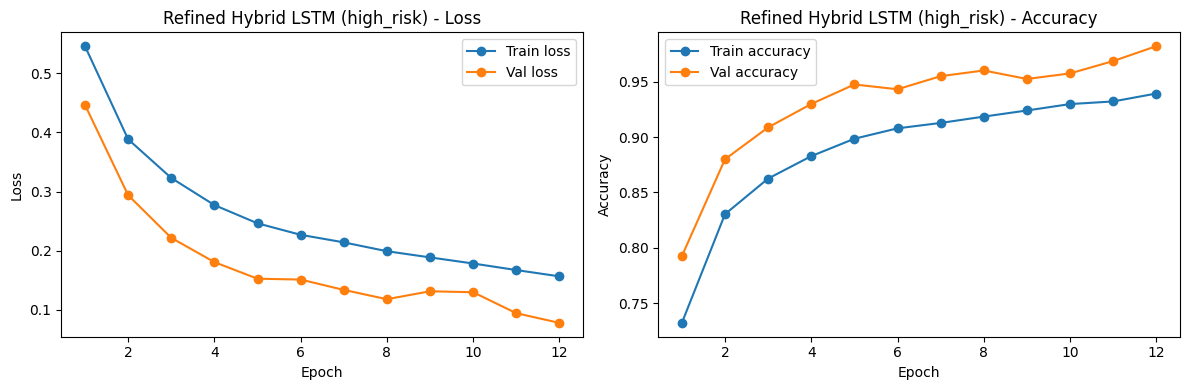

In [25]:
# Plotting for high_risk LSTM
plot_training_curves(history_hr_ref, title_prefix="Refined Hybrid LSTM (high_risk)")

### Interpretation
For the hybrid LSTM on the high_risk outcome, validation accuracy increases steadily from about 0.79 to 0.98 while validation loss continues to fall, suggesting stable learning rather than overfitting. On the held-out test set, the model achieves almost 0.98 accuracy, with precision and recall between 0.96 and 1.00 for both classes and a ROC-AUC of almost 0.9997, indicating almost perfect seperation of high-risk and non-hogh-risk visits. In contrast, both the base and refined LSTM architectures remain at a guessing level for admitted_bin, reinforcing that there is strong, learnable signal in the engineered high-risk label but essentially no predictive signal for admission status in this synthetic dataset.


### ROC Curves for Hybrid LSTM


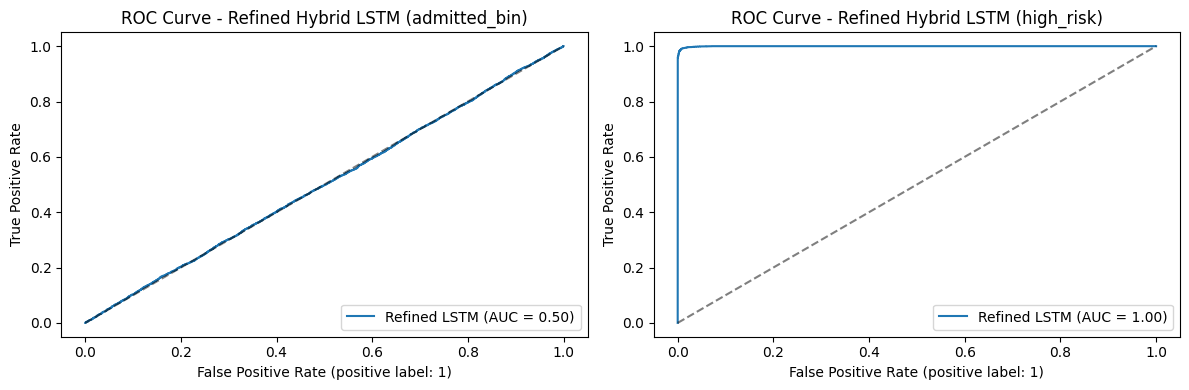

AUC (admitted_bin, Refined LSTM): 0.5003833051724642
AUC (high_risk, Refined LSTM): 0.9996712680996248


In [30]:
from sklearn.metrics import roc_curve, roc_auc_score

#AUC values
auc_adm_ref = roc_auc_score(y_test_adm, y_proba_adm_lstm_ref)
auc_hr_ref = roc_auc_score(y_test_hr, y_proba_hr_lstm_ref)

# ROC points
fpr_adm_ref, tpr_adm_ref, _ = roc_curve(y_test_adm, y_proba_adm_lstm_ref)
fpr_hr_ref, tpr_hr_ref, _ = roc_curve(y_test_hr, y_proba_hr_lstm_ref)

plt.figure(figsize=(12, 4))

# admitted_bin
plt.subplot(1, 2, 1)
plt.plot(fpr_adm_ref, tpr_adm_ref, label=f"Refined LSTM (AUC = {auc_adm_ref:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate (positive label: 1)")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Refined Hybrid LSTM (admitted_bin)")
plt.legend(loc="lower right")

# high_risk
plt.subplot(1, 2, 2)
plt.plot(fpr_hr_ref, tpr_hr_ref, label=f"Refined LSTM (AUC = {auc_hr_ref:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate (positive label: 1)")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Refined Hybrid LSTM (high_risk)")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

print("AUC (admitted_bin, Refined LSTM):", auc_adm_ref)
print("AUC (high_risk, Refined LSTM):", auc_hr_ref)

### Interpretation
for the refined hybrid LSTM, the ROC curves aagain show a contrast between the two targets. For admitted_bin, the ROC curv lies essentially on the diagonal (AUC almost 0.50), confirming that even a deeper LSTM cannot learn a meaningful admission signal from the raw synthetic data. In contrast, for high_risk the refined model achieves near-perfect discrimination(AUC almost 0.9997), with the ROC curve hugging the top-left corner. This further reinforces that the engineered high-risk label is strongly supported by the combined clinical text and numeric features, whereas admission status is not.


## Summary of Traditional and LSTM Model Results


In [43]:
def collect_metrics(y_true, y_pred, y_score, model_name, label_name):
    return {
        "Model": model_name,
        "Label": label_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_score),
    }

rows = []
# Traditional Models


# Logistic Regression
rows.append(collect_metrics(y_test_adm, y_pred_adm,   y_proba_adm,   "LogReg (Base)",   "admitted_bin"))
rows.append(collect_metrics(y_test_hr, y_pred_hr,   y_proba_hr,   "LogReg (Base)",   "high_risk"))
# Logistic Regression Tuned
rows.append(collect_metrics(y_test_adm, y_pred_adm_tuned,   y_proba_adm_tuned,   "LogReg (tuned)",   "admitted_bin"))
rows.append(collect_metrics(y_test_hr, y_pred_hr_tuned,   y_proba_hr_tuned,   "LogReg (tuned)",   "high_risk"))

# Linear SVM
rows.append(collect_metrics(y_test_adm, y_pred_svm_adm,   y_scores_svm_adm,   "LinearSVM (Base)",   "admitted_bin"))
rows.append(collect_metrics(y_test_hr, y_pred_svm_hr,   y_scores_svm_hr,   "LinearSVM (Base)",   "high_risk"))
# Linear SVM tuned
rows.append(collect_metrics(y_test_adm, y_pred_svm_adm_tuned,   y_scores_svm_adm_tuned,   "LinearSVM (tuned)",   "admitted_bin"))
rows.append(collect_metrics(y_test_hr, y_pred_svm_hr_tuned,   y_scores_svm_hr_tuned,   "LinearSVM (tuned)",   "high_risk"))


# Deep Models

# LSTM
rows.append(collect_metrics(y_test_adm, y_pred_adm_lstm,   y_proba_adm_lstm,   "Hybrid LSTM (Base)",   "admitted_bin"))
rows.append(collect_metrics(y_test_hr, y_pred_hr_lstm,   y_proba_hr_lstm,   "Hybrid LSTM (Base)",   "high_risk"))
# LSTM Refined
rows.append(collect_metrics(y_test_adm, y_pred_adm_lstm_ref,   y_proba_adm_lstm_ref,   "LSTM (Refined)",   "admitted_bin"))
rows.append(collect_metrics(y_test_hr, y_pred_hr_lstm_ref,   y_proba_hr_lstm_ref,   "LSTM (Refined)",   "high_risk"))


metrics_df = pd.DataFrame(rows)
#Sort by Label then Model
metrics_df.sort_values(["Label", "Model"], inplace=True)
display(metrics_df.round(3))

# Saving as CSV
metrics_df.to_csv("model_metrics_summary.csv", index=False)
# Saving as pickle to preserve dtypes 
metrics_df.to_pickle("model_metrics_summary.pkl")

,Model,Label,Accuracy,Precision,Recall,ROC_AUC
8,Hybrid LSTM (Base),admitted_bin,0.501,0.501,0.974,0.501
10,LSTM (Refined),admitted_bin,0.501,0.501,0.697,0.500
4,LinearSVM (Base),admitted_bin,0.499,0.500,0.543,0.495
6,LinearSVM (tuned),admitted_bin,0.499,0.500,0.540,0.496
0,LogReg (Base),admitted_bin,0.499,0.500,0.539,0.495
2,LogReg (tuned),admitted_bin,0.499,0.500,0.542,0.495
9,Hybrid LSTM (Base),high_risk,0.917,0.961,0.898,0.973
11,LSTM (Refined),high_risk,0.981,0.999,0.969,1.000
5,LinearSVM (Base),high_risk,0.811,0.833,0.854,0.896
7,LinearSVM (tuned),high_risk,0.804,0.862,0.798,0.896


### Interpretation
Across all traditional models(logistic regression and linear SVM, base and tuned), admitted_bin performance stays at guessing level (accuracy almost 0.50, ROC-AUC almost 0.49 - 0.50), confirming that admission status is not learnable from this limited synthetic dataset. In contrast, for high_risk, traditional models achieve moderate-strong performance (accuracy almost 0.80 - 0.82, ROC-AUC almost 0.90). The hybrid LSTM models clearly out perform them. The base hybrid LSTM already reaches accuracy almost 0.92, ROC-AUC almost .97, and the refined hybrid LSTM further improves to accuracy approximately 0.98, precision almost 1.00, recall almost 0.97, ROC-AUC almost1.00, indicating almost perfect separation between high-risk and non-high-risk visits.
